In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [35]:
file = pd.read_csv('../datasets/feature_engineered_pima.csv')
train = file.copy()
train.head()
train.describe()
train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome',
       'Glucose_Insulin_ratio', 'Insulin_Glucose_ratio', 'BMI_Age_ratio',
       'Age_BMI_interaction', 'Skin_BMI_ratio', 'BloodPressure_Age_ratio'],
      dtype='object')

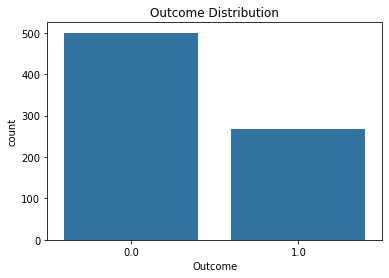

In [36]:
sns.countplot(x='Outcome',data=train)
plt.title('Outcome Distribution')
plt.show()

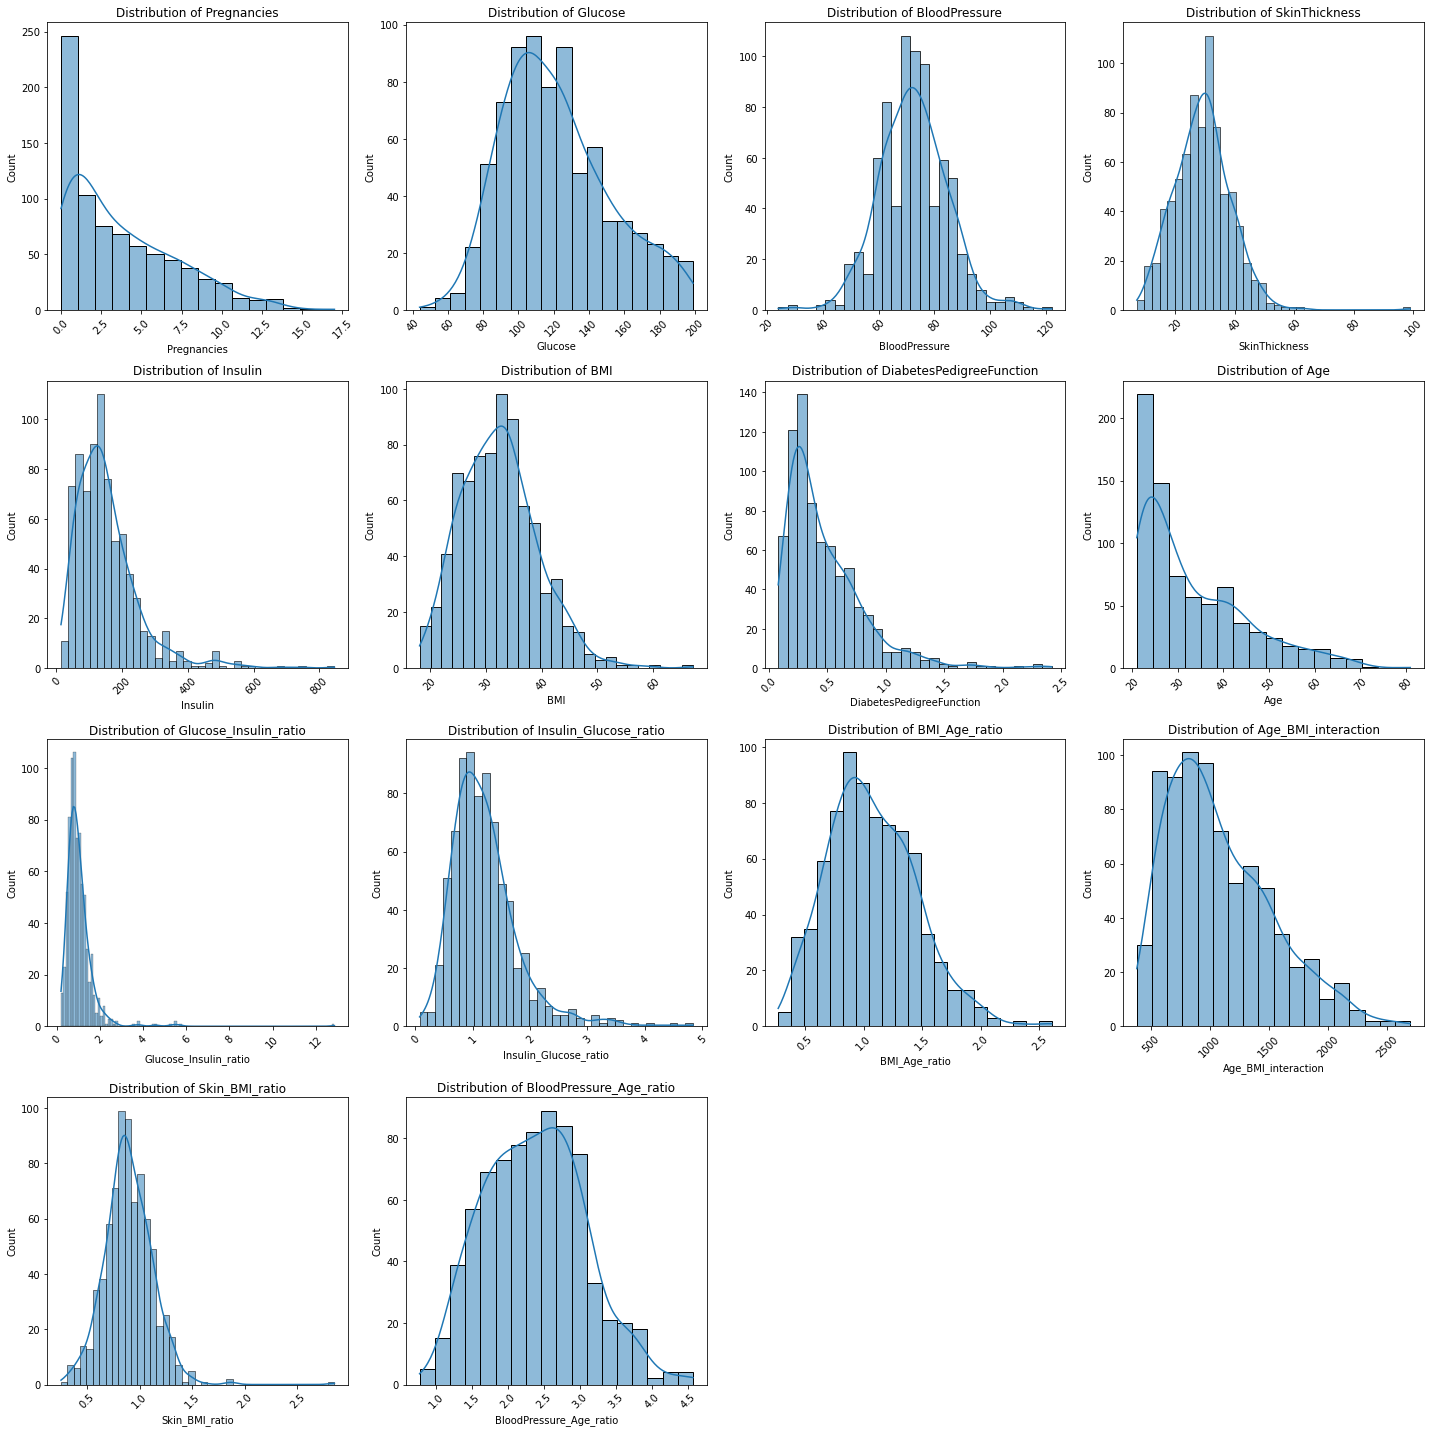

In [37]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 
       'Glucose_Insulin_ratio', 'Insulin_Glucose_ratio', 'BMI_Age_ratio',
       'Age_BMI_interaction', 'Skin_BMI_ratio', 'BloodPressure_Age_ratio']

# 计算需要的子图数量
n_cols = len(cols)
n_rows = (n_cols + 3) // 4  # 向上取整，每行4个图

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # 将2D数组展平为1D，便于索引

for i, col in enumerate(cols):
    sns.histplot(train[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

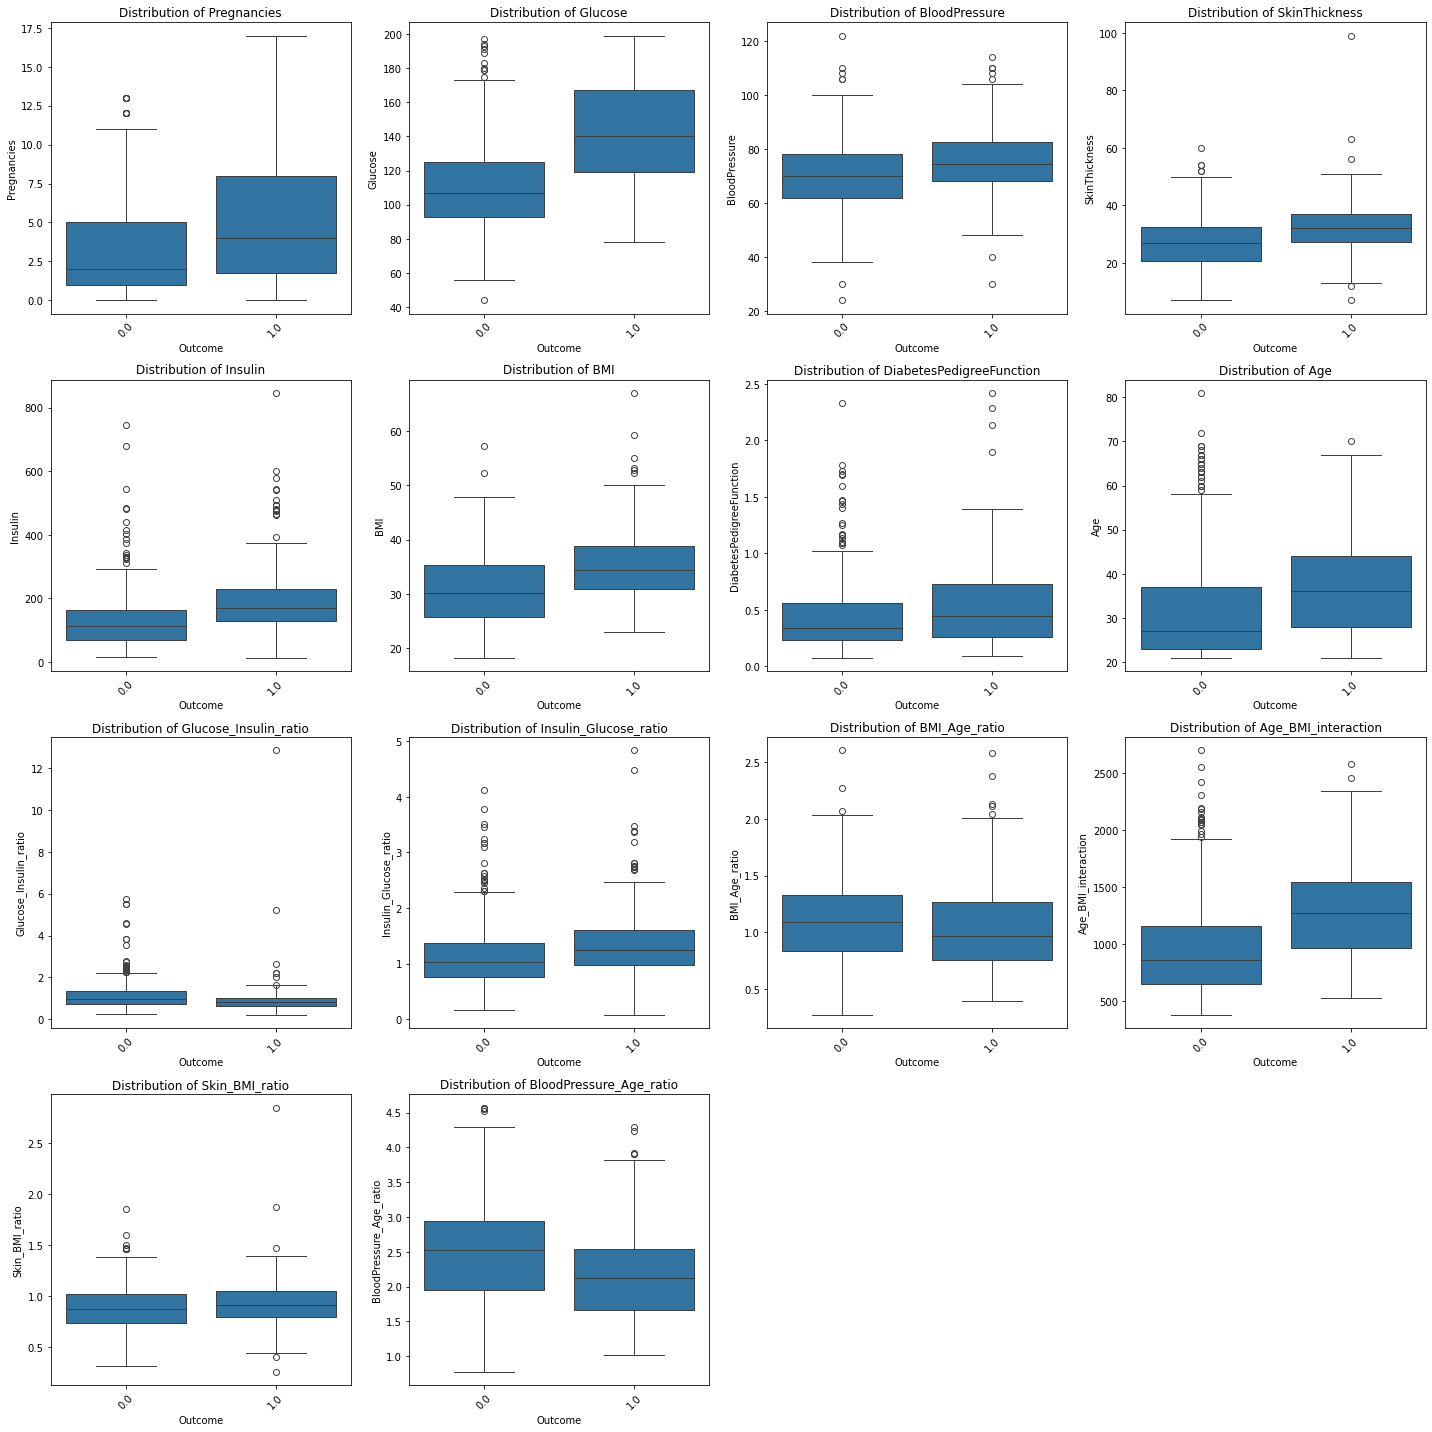

In [38]:
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # 将2D数组展平为1D，便于索引

for i, col in enumerate(cols):
    sns.boxplot(x='Outcome',y=col, data=train,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

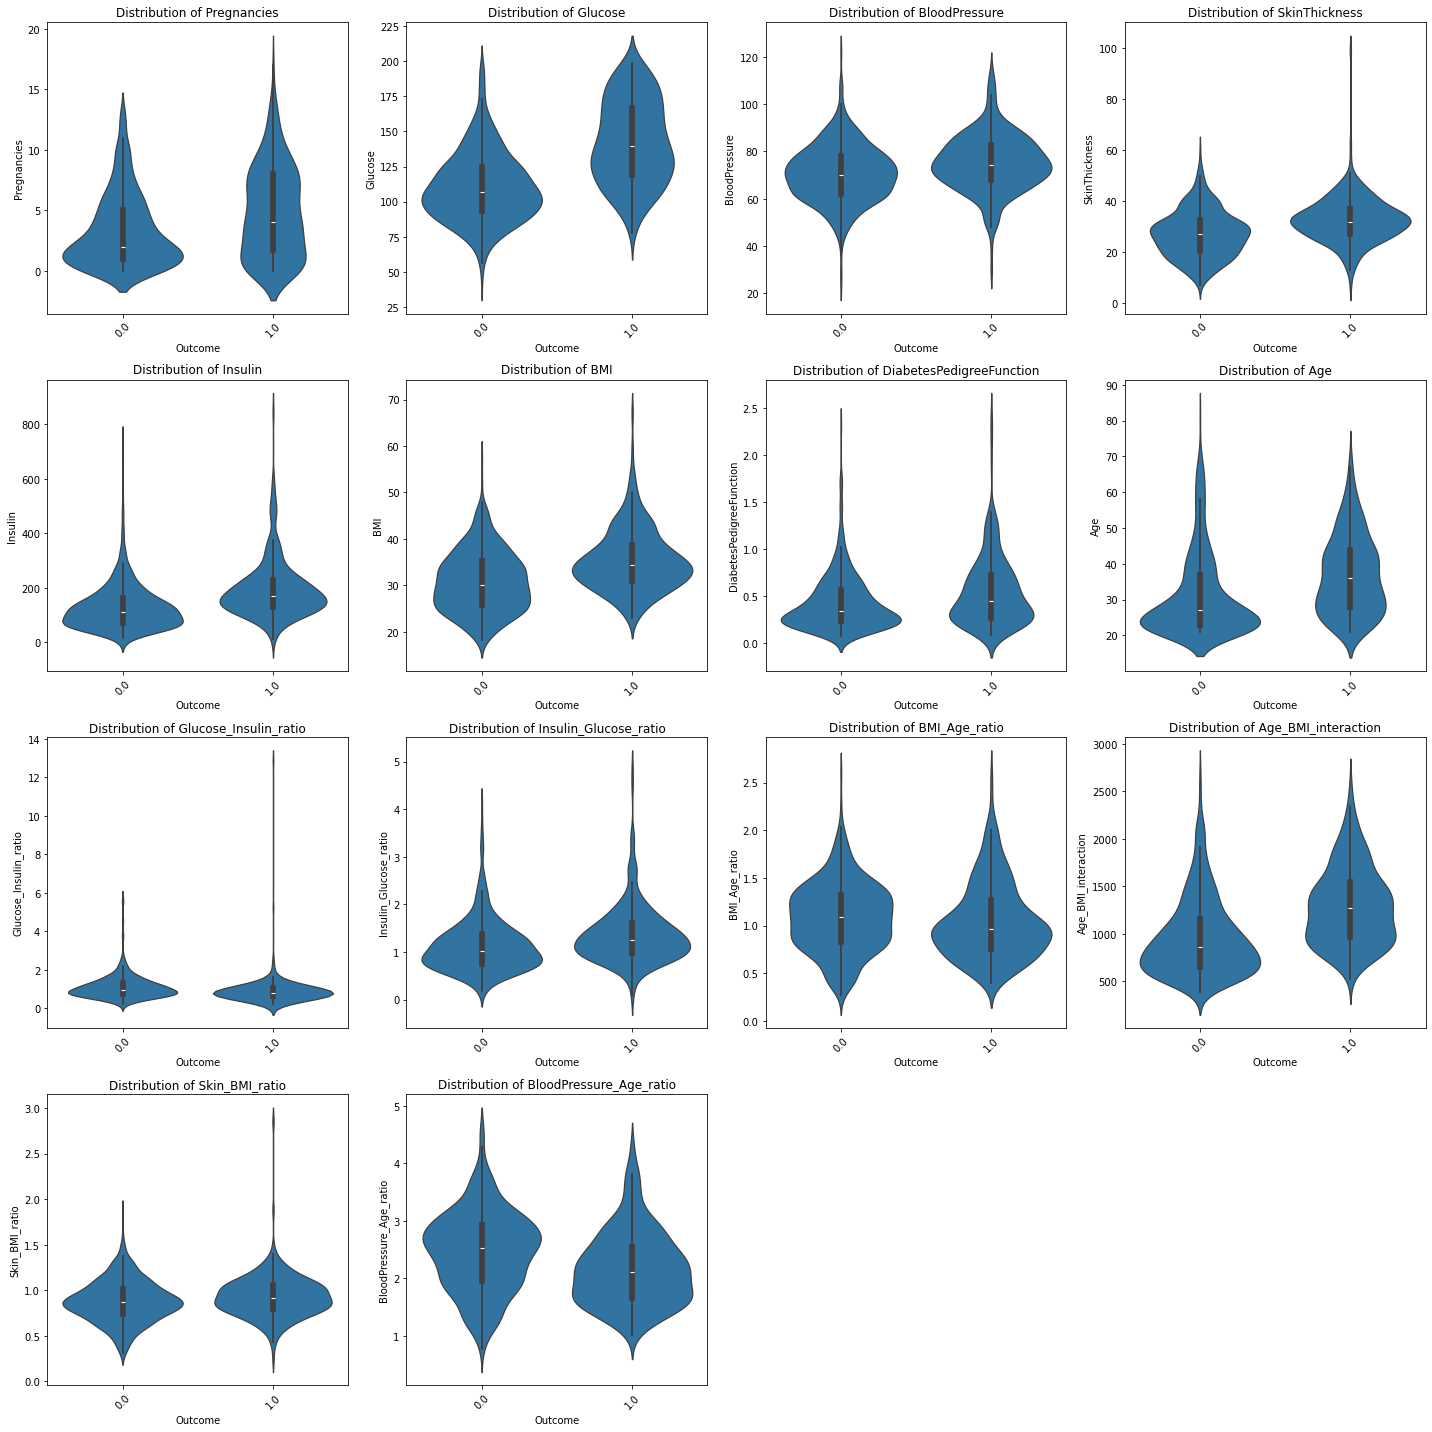

In [39]:
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # 将2D数组展平为1D，便于索引

for i, col in enumerate(cols):
    sns.violinplot(x='Outcome',y=col, data=train,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

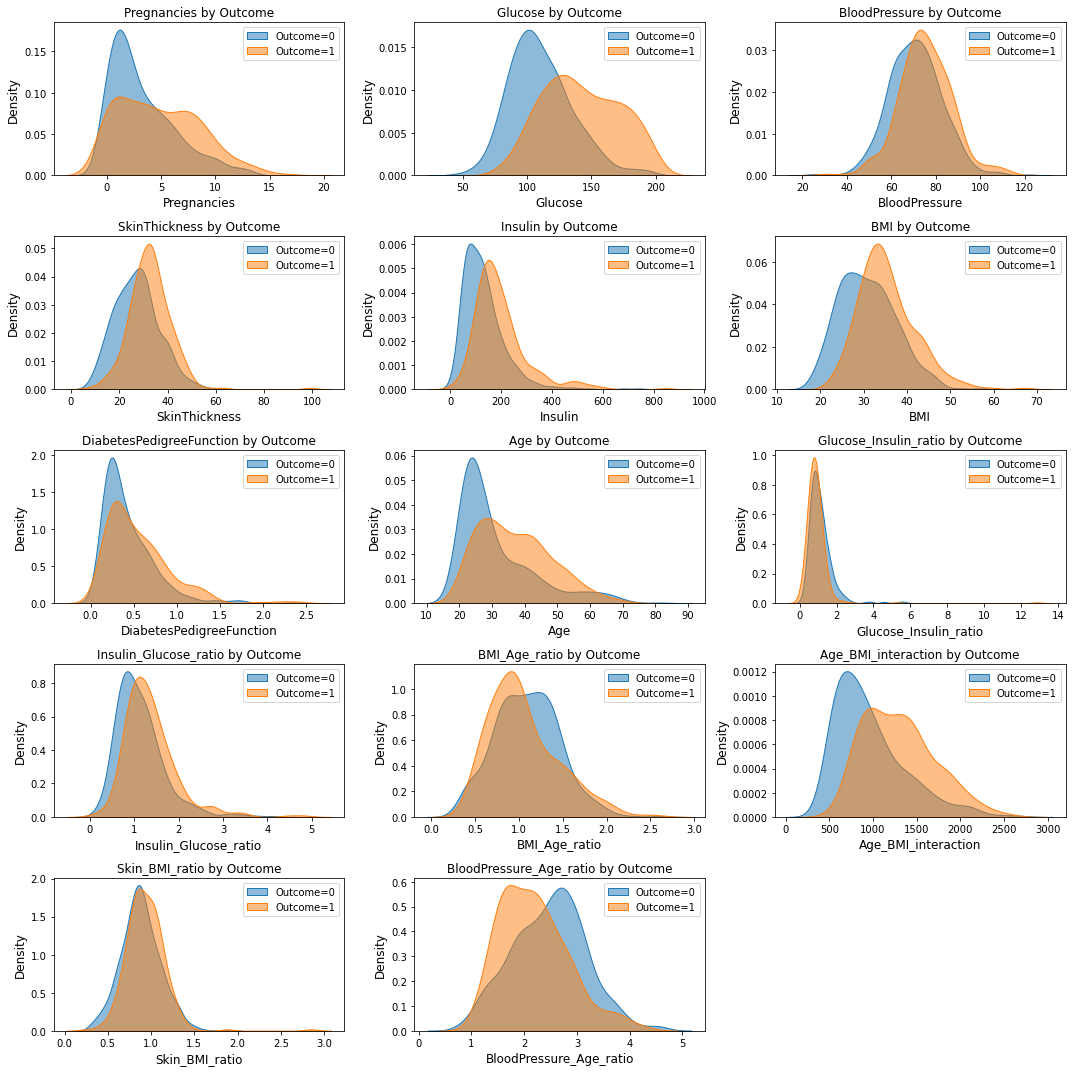

: 

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.flatten()  

plot_idx = 0
for i, col in enumerate(cols):  
    if col == 'Outcome':
        continue
    
    ax = axes[plot_idx]
    
    for outcome in [0, 1]:
        subset = train[train['Outcome'] == outcome][col]
        sns.kdeplot(data=subset, label=f'Outcome={outcome}', ax=ax, fill=True, alpha=0.5)
    
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{col} by Outcome')
    ax.legend()
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()